In [1]:
import os
import cv2
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

class MCDRPPGDataset(Dataset):
    def __init__(self, data_dir=r"C:\Users\VICTUS\HemoVision\data\vitalscan-clinic\MCD-rPPG", transform=None):
        self.data_dir = data_dir
        self.video_dir = os.path.join(data_dir, "video")
        self.ppg_dir = os.path.join(data_dir, "ppg_sync")  # Or "ppg" depending on alignment target
        self.transform = transform
        
        # Load database metadata index
        db_path = os.path.join(data_dir, "db")
        if os.path.exists(db_path):
            self.metadata = pd.read_csv(db_path)
        else:
            # Fallback: scan video directory directly
            self.video_files = [f for f in os.listdir(self.video_dir) if f.endswith(('.mp4', '.avi'))]

    def __len__(self):
        return len(self.video_files)

    def __getitem__(self, idx):
        video_name = self.video_files[idx]
        video_path = os.path.join(self.video_dir, video_name)
        
        # 1. Read Video Frames
        cap = cv2.VideoCapture(video_path)
        frames = []
        while cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                break
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frames.append(frame)
        cap.release()
        
        # Convert to array / tensor
        frames = np.array(frames) # Shape: (T, H, W, C)
        
        # 2. Read Ground-truth PPG (assumes matching filename in ppg_sync)
        ppg_filename = os.path.splitext(video_name)[0] + ".csv" # or .npy / .txt depending on format
        ppg_path = os.path.join(self.ppg_dir, ppg_filename)
        
        ppg_signal = np.load(ppg_path) if ppg_path.endswith('.npy') else pd.read_csv(ppg_path).values
        
        if self.transform:
            frames = self.transform(frames)
            
        return torch.tensor(frames, dtype=torch.float32), torch.tensor(ppg_signal, dtype=torch.float32)

# Quick sanity check runner
if __name__ == "__main__":
    DATA_PATH = r"C:\Users\VICTUS\HemoVision\data\vitalscan-clinic\MCD-rPPG"
    dataset = MCDRPPGDataset(data_dir=DATA_PATH)
    print(f"Successfully located {len(dataset)} sample files.")

Successfully located 3600 sample files.


In [2]:
import cv2
import numpy as np
import mediapipe as mp

class FaceROIExtractor:
    def __init__(self):
        self.mp_face_mesh = mp.solutions.face_mesh
        self.face_mesh = self.mp_face_mesh.FaceMesh(
            static_image_mode=False,
            max_num_faces=1,
            refine_landmarks=True,
            min_detection_confidence=0.5,
            min_tracking_confidence=0.5
        )
        
        # Approximate landmark indices for 8 key PPG zones
        # Zone 1-2: Forehead | Zone 3-4: Left Cheek | Zone 5-6: Right Cheek | Zone 7: Nose/Mid | Zone 8: Chin
        self.ROI_INDICES = [
            [10, 338, 297, 332],  # Forehead Left
            [10, 109, 67, 103],   # Forehead Right
            [117, 118, 101, 205], # Left Cheek Upper
            [138, 135, 210, 211], # Left Cheek Lower
            [346, 347, 330, 425], # Right Cheek Upper
            [367, 364, 430, 431], # Right Cheek Lower
            [1, 2, 98, 327],      # Nose / Mid-face
            [152, 148, 176, 377]  # Chin Area
        ]

    def extract_rois_from_frame(self, frame_rgb):
        """
        Input: RGB frame (H, W, 3)
        Output: Tensor/Array of 8 Cropped/Pooled ROI features (8, 3) representing average RGB
        """
        h, w, _ = frame_rgb.shape
        results = self.face_mesh.process(frame_rgb)
        
        if not results.multi_face_landmarks:
            # Fallback if face is missed in a frame: return zeros or previous frame state
            return np.zeros((8, 3), dtype=np.float32)
            
        landmarks = results.multi_face_landmarks[0].landmark
        roi_means = []

        for indices in self.ROI_INDICES:
            # Get pixel coordinates for the polygon
            pts = np.array([[int(landmarks[idx].x * w), int(landmarks[idx].y * h)] for idx in indices], np.int32)
            
            # Create a bounding mask for spatial averaging
            mask = np.zeros((h, w), dtype=np.uint8)
            cv2.fillConvexPoly(mask, pts, 1)
            
            # Calculate mean RGB inside the ROI polygon
            mean_val = cv2.mean(frame_rgb, mask=mask)[:3]
            roi_means.append(mean_val)

        return np.array(roi_means, dtype=np.float32) # Shape: (8, 3)

# Sanity Check
extractor = FaceROIExtractor()
print("ROI Extractor initialized cleanly.")

ROI Extractor initialized cleanly.


In [3]:
# Grab 1 video from dataset to test extraction
sample_video_path = os.path.join(dataset.video_dir, dataset.video_files[0])
cap = cv2.VideoCapture(sample_video_path)

roi_signals = []
frame_count = 0

while cap.isOpened() and frame_count < 150: # Test on first 150 frames (~5 seconds at 30fps)
    ret, frame = cap.read()
    if not ret:
        break
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    
    # Extract 8-ROI RGB means
    rois = extractor.extract_rois_from_frame(frame_rgb)
    roi_signals.append(rois)
    frame_count += 1

cap.release()

roi_signals = np.array(roi_signals) # Shape: (T, 8, 3)
print(f"Extracted ROI Signal Shape: {roi_signals.shape} (Frames, ROIs, Channels)")

c:\Users\VICTUS\HemoVision\.venv310\lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


Extracted ROI Signal Shape: (150, 8, 3) (Frames, ROIs, Channels)


In [4]:
import torch

def preprocess_roi_signals(roi_signals):
    """
    Input: roi_signals array of shape (T, 8, 3)
    Output: Normalized PyTorch Tensor of shape (1, 24, T)
    """
    # 1. Reshape (T, 8, 3) -> (T, 24) by flattening ROI and RGB channels
    T, num_rois, num_channels = roi_signals.shape
    flattened_signals = roi_signals.reshape(T, num_rois * num_channels)
    
    # 2. Temporal Zero-Mean Unit-Variance Normalization per feature channel
    mean = np.mean(flattened_signals, axis=0, keepdims=True)
    std = np.std(flattened_signals, axis=0, keepdims=True) + 1e-8
    norm_signals = (flattened_signals - mean) / std
    
    # 3. Transpose (T, 24) -> (24, T) for PyTorch 1D Convolutions
    tensor_signals = torch.tensor(norm_signals, dtype=torch.float32).T
    
    # 4. Add Batch Dimension -> (1, 24, T)
    tensor_signals = tensor_signals.unsqueeze(0)
    
    return tensor_signals

# Test on your extracted signals
input_tensor = preprocess_roi_signals(roi_signals)
print(f"Preprocessed Model Input Tensor Shape: {input_tensor.shape}")

Preprocessed Model Input Tensor Shape: torch.Size([1, 24, 150])


In [5]:
import torch.nn as nn
import torch.nn.functional as F

class ConvBlock1D(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1):
        super().__init__()
        self.conv = nn.Conv1d(in_channels, out_channels, kernel_size, stride, padding)
        self.bn = nn.BatchNorm1d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        
    def forward(self, x):
        return self.relu(self.bn(self.conv(x)))

class HemoVisionSCNN(nn.Module):
    def __init__(self, in_channels=24, hidden_dim=64):
        super().__init__()
        
        # Bottom-up feature extractor (Encoder)
        self.enc1 = ConvBlock1D(in_channels, hidden_dim, kernel_size=5, padding=2)
        self.pool1 = nn.MaxPool1d(kernel_size=2, stride=2)
        
        self.enc2 = ConvBlock1D(hidden_dim, hidden_dim * 2, kernel_size=5, padding=2)
        self.pool2 = nn.MaxPool1d(kernel_size=2, stride=2)
        
        self.enc3 = ConvBlock1D(hidden_dim * 2, hidden_dim * 4, kernel_size=5, padding=2)
        
        # 1D Feature Pyramid Network (FPN) connections
        self.lat3 = nn.Conv1d(hidden_dim * 4, hidden_dim, kernel_size=1)
        self.lat2 = nn.Conv1d(hidden_dim * 2, hidden_dim, kernel_size=1)
        self.lat1 = nn.Conv1d(hidden_dim, hidden_dim, kernel_size=1)
        
        # Signal Reconstruction Head (Outputs estimated 1D PPG wave across time)
        self.ppg_head = nn.Sequential(
            ConvBlock1D(hidden_dim, 32, kernel_size=3, padding=1),
            nn.Conv1d(32, 1, kernel_size=1)
        )
        
    def forward(self, x):
        # x shape: (B, 24, T)
        
        # Bottom-up path
        e1 = self.enc1(x)         # (B, 64, T)
        e2 = self.enc2(self.pool1(e1)) # (B, 128, T/2)
        e3 = self.enc3(self.pool2(e2)) # (B, 256, T/4)
        
        # Top-down FPN path
        p3 = self.lat3(e3)
        
        p2 = self.lat2(e2) + F.interpolate(p3, size=e2.shape[2], mode='linear', align_corners=False)
        p1 = self.lat1(e1) + F.interpolate(p2, size=e1.shape[2], mode='linear', align_corners=False)
        
        # Output 1D PPG Waveform
        ppg_wave = self.ppg_head(p1) # (B, 1, T)
        return ppg_wave.squeeze(1)   # (B, T)

# Instantiation & Verification
model = HemoVisionSCNN()
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"HemoVision SCNN Model Initialized! Total Trainable Parameters: {num_params:,}")

# Run a test forward pass
output_ppg = model(input_tensor)
print(f"Output Predicted PPG Waveform Shape: {output_ppg.shape} (Batch, Time)")

HemoVision SCNN Model Initialized! Total Trainable Parameters: 248,961
Output Predicted PPG Waveform Shape: torch.Size([1, 150]) (Batch, Time)


In [6]:
import torch
import torch.nn as nn

class PPGCompositeLoss(nn.Module):
    def __init__(self, alpha=0.7, beta=0.3):
        super().__init__()
        self.alpha = alpha  # Weight for Pearson Loss
        self.beta = beta    # Weight for Frequency Loss
        self.mse = nn.MSELoss()

    def pearson_loss(self, pred, target):
        """Calculates 1 - Pearson Correlation Coefficient."""
        pred_mean = torch.mean(pred, dim=-1, keepdim=True)
        target_mean = torch.mean(target, dim=-1, keepdim=True)
        
        pred_sub = pred - pred_mean
        target_sub = target - target_mean
        
        cov = torch.sum(pred_sub * target_sub, dim=-1)
        var_pred = torch.sum(pred_sub ** 2, dim=-1)
        var_target = torch.sum(target_sub ** 2, dim=-1)
        
        r = cov / (torch.sqrt(var_pred * var_target) + 1e-8)
        return torch.mean(1.0 - r)

    def frequency_loss(self, pred, target):
        """L1 loss on real-valued Fast Fourier Transform magnitude spectra."""
        fft_pred = torch.abs(torch.fft.rfft(pred, dim=-1))
        fft_target = torch.abs(torch.fft.rfft(target, dim=-1))
        return F.l1_loss(fft_pred, fft_target)

    def forward(self, pred, target):
        l_pearson = self.pearson_loss(pred, target)
        l_freq = self.frequency_loss(pred, target)
        
        total_loss = (self.alpha * l_pearson) + (self.beta * l_freq)
        return total_loss, l_pearson, l_freq

# Verify Loss Initializer
criterion = PPGCompositeLoss()
dummy_target = torch.randn_like(output_ppg)
loss_val, p_loss, f_loss = criterion(output_ppg, dummy_target)

print(f"Loss Function Initialized Cleanly!")
print(f"Sample Total Loss: {loss_val.item():.4f} | Pearson: {p_loss.item():.4f} | Freq: {f_loss.item():.4f}")

Loss Function Initialized Cleanly!
Sample Total Loss: 3.5252 | Pearson: 1.0126 | Freq: 9.3879


In [7]:
import os
import pandas as pd
import numpy as np

ppg_dir = r"C:\Users\VICTUS\HemoVision\data\vitalscan-clinic\MCD-rPPG\ppg_sync"
if not os.path.exists(ppg_dir):
    ppg_dir = r"C:\Users\VICTUS\HemoVision\data\vitalscan-clinic\MCD-rPPG\ppg"

# Find first available file
sample_files = os.listdir(ppg_dir)
print(f"Target Ground-Truth Directory: {ppg_dir}")
print(f"Sample GT Files found: {sample_files[:5]}")

sample_gt_path = os.path.join(ppg_dir, sample_files[0])

# Inspect content structure
if sample_gt_path.endswith('.csv'):
    gt_df = pd.read_csv(sample_gt_path)
    print("\nGT CSV Columns:", gt_df.columns.tolist())
    print("GT CSV Shape:", gt_df.shape)
elif sample_gt_path.endswith('.npy'):
    gt_arr = np.load(sample_gt_path)
    print("\nGT Array Shape:", gt_arr.shape)
else:
    with open(sample_gt_path, 'r') as f:
        lines = [f.readline() for _ in range(5)]
    print("\nGT File First Lines:", lines)

Target Ground-Truth Directory: C:\Users\VICTUS\HemoVision\data\vitalscan-clinic\MCD-rPPG\ppg_sync
Sample GT Files found: ['1020_FullHDwebcam_after.txt', '1020_FullHDwebcam_before.txt', '1020_IriunWebcam_after.txt', '1020_IriunWebcam_before.txt', '1020_USBVideo_after.txt']

GT File First Lines: ['104 0.016954\n', '106 0.000997\n', '105 0.000998\n', '77 0.0\n', '35 0.000948\n']


In [8]:
import numpy as np

def load_ground_truth_ppg(txt_path, target_length=150):
    """
    Reads space-separated ppg_sync text files and extracts the normalized 1D PPG wave.
    """
    # Load 2-column text file
    data = np.loadtxt(txt_path)
    
    # Extract 2nd column (PPG signal)
    if data.ndim == 2 and data.shape[1] >= 2:
        ppg_signal = data[:, 1]
    else:
        ppg_signal = data.squeeze()
        
    # Interpolate/Resample to match video frame count T
    current_length = len(ppg_signal)
    if current_length != target_length:
        x_old = np.linspace(0, 1, current_length)
        x_new = np.linspace(0, 1, target_length)
        ppg_signal = np.interp(x_new, x_old, ppg_signal)
        
    # Normalize ground truth PPG (Zero-Mean, Unit-Variance)
    mean = np.mean(ppg_signal)
    std = np.std(ppg_signal) + 1e-8
    ppg_norm = (ppg_signal - mean) / std
    
    return torch.tensor(ppg_norm, dtype=torch.float32).unsqueeze(0) # Shape: (1, T)

# Test on sample GT file
sample_gt_full_path = os.path.join(ppg_dir, sample_files[0])
gt_tensor = load_ground_truth_ppg(sample_gt_full_path, target_length=150)
print(f"Loaded Ground Truth PPG Tensor Shape: {gt_tensor.shape}")

Loaded Ground Truth PPG Tensor Shape: torch.Size([1, 150])


In [9]:
import torch.optim as optim

# 1. Initialize Model & Optimizer
model = HemoVisionSCNN()
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = PPGCompositeLoss(alpha=0.7, beta=0.3)

# 2. Map sample video to corresponding GT file
sample_video_name = dataset.video_files[0]
base_name = os.path.splitext(sample_video_name)[0]
matched_gt_file = base_name + ".txt"
gt_file_path = os.path.join(ppg_dir, matched_gt_file)

# Fallback if filename naming slightly differs
if not os.path.exists(gt_file_path):
    gt_file_path = os.path.join(ppg_dir, sample_files[0])

# 3. Load Target Ground Truth PPG
target_ppg = load_ground_truth_ppg(gt_file_path, target_length=150)

# 4. Forward + Backprop Verification Step
model.train()
optimizer.zero_grad()

# Forward pass on preprocessed input tensor
pred_ppg = model(input_tensor) # Shape: (1, 150)

# Calculate Loss
loss, p_loss, f_loss = criterion(pred_ppg, target_ppg)

# Backward pass & Optimizer Step
loss.backward()
optimizer.step()

print(f"--- Training Step Executed Successfully ---")
print(f"Matched Video: {sample_video_name}")
print(f"Matched GT File: {os.path.basename(gt_file_path)}")
print(f"Initial Composite Loss: {loss.item():.4f}")
print(f"Pearson Loss: {p_loss.item():.4f} | Frequency Loss: {f_loss.item():.4f}")

--- Training Step Executed Successfully ---
Matched Video: 1020_FullHDwebcam_after.avi
Matched GT File: 1020_FullHDwebcam_after.txt
Initial Composite Loss: 2.3052
Pearson Loss: 0.9011 | Frequency Loss: 5.5814


In [10]:
import torch.optim as optim

# Re-initialize model & optimizer for fresh test
model = HemoVisionSCNN()
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = PPGCompositeLoss(alpha=0.7, beta=0.3)

num_epochs = 50
print("--- Starting Single-Sample Overfitting Test ---")

for epoch in range(1, num_epochs + 1):
    model.train()
    optimizer.zero_grad()
    
    # Forward Pass
    pred_ppg = model(input_tensor)
    
    # Compute Loss
    loss, p_loss, f_loss = criterion(pred_ppg, target_ppg)
    
    # Backward Pass & Optimize
    loss.backward()
    optimizer.step()
    
    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch [{epoch:02d}/{num_epochs}] | Total Loss: {loss.item():.4f} | Pearson Loss: {p_loss.item():.4f} | Freq Loss: {f_loss.item():.4f}")

print("Overfitting test complete!")

--- Starting Single-Sample Overfitting Test ---
Epoch [01/50] | Total Loss: 2.4832 | Pearson Loss: 0.8934 | Freq Loss: 6.1926
Epoch [10/50] | Total Loss: 0.6251 | Pearson Loss: 0.1798 | Freq Loss: 1.6640
Epoch [20/50] | Total Loss: 0.2988 | Pearson Loss: 0.1330 | Freq Loss: 0.6858
Epoch [30/50] | Total Loss: 0.2011 | Pearson Loss: 0.1014 | Freq Loss: 0.4337
Epoch [40/50] | Total Loss: 0.1801 | Pearson Loss: 0.0887 | Freq Loss: 0.3935
Epoch [50/50] | Total Loss: 0.1475 | Pearson Loss: 0.0783 | Freq Loss: 0.3088
Overfitting test complete!


In [11]:
import os
import time
import torch
import torch.optim as optim

# 1. Setup Device & Directory Paths
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using compute device: {device}")

video_dir = dataset.video_dir
ppg_dir = r"C:\Users\VICTUS\HemoVision\data\vitalscan-clinic\MCD-rPPG\ppg_sync"

# Collect all matching video-GT pairs
all_videos = [f for f in os.listdir(video_dir) if f.endswith(('.avi', '.mp4'))]
valid_pairs = []

for v_file in all_videos:
    base = os.path.splitext(v_file)[0]
    gt_file = base + ".txt"
    gt_path = os.path.join(ppg_dir, gt_file)
    if os.path.exists(gt_path):
        valid_pairs.append((os.path.join(video_dir, v_file), gt_path))

print(f"Found {len(valid_pairs)} perfectly paired Video-GT samples for training.")

# 2. Re-initialize Model, Optimizer, Loss for full training
model = HemoVisionSCNN().to(device)
optimizer = optim.AdamW(model.parameters(), lr=5e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
criterion = PPGCompositeLoss(alpha=0.7, beta=0.3)

# 3. Training Config
NUM_SAMPLES_TO_TRAIN = min(50, len(valid_pairs)) # Start with first 50 matched videos
EPOCHS = 10
best_loss = float('inf')

print(f"\n--- Launching Full Training Run on {NUM_SAMPLES_TO_TRAIN} Videos ({EPOCHS} Epochs) ---")

start_time = time.time()

for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss = 0.0
    running_p_loss = 0.0
    running_f_loss = 0.0
    processed_count = 0
    
    for idx in range(NUM_SAMPLES_TO_TRAIN):
        v_path, g_path = valid_pairs[idx]
        
        # Extract ROIs from Video
        cap = cv2.VideoCapture(v_path)
        roi_signals = []
        f_count = 0
        while cap.isOpened() and f_count < 150:
            ret, frame = cap.read()
            if not ret:
                break
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            rois = extractor.extract_rois_from_frame(frame_rgb)
            roi_signals.append(rois)
            f_count += 1
        cap.release()
        
        if len(roi_signals) < 150:
            continue # Skip corrupted/short video samples
            
        roi_signals = np.array(roi_signals)
        
        # Preprocess Tensor & GT
        inp_tensor = preprocess_roi_signals(roi_signals).to(device)
        tgt_tensor = load_ground_truth_ppg(g_path, target_length=150).to(device)
        
        # Forward & Backprop
        optimizer.zero_grad()
        pred_ppg = model(inp_tensor)
        
        loss, p_loss, f_loss = criterion(pred_ppg, tgt_tensor)
        loss.backward()
        
        # Gradient clipping to prevent exploding gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        running_loss += loss.item()
        running_p_loss += p_loss.item()
        running_f_loss += f_loss.item()
        processed_count += 1
        
    epoch_loss = running_loss / max(1, processed_count)
    epoch_p = running_p_loss / max(1, processed_count)
    epoch_f = running_f_loss / max(1, processed_count)
    
    scheduler.step(epoch_loss)
    
    print(f"Epoch [{epoch:02d}/{EPOCHS}] | Avg Loss: {epoch_loss:.4f} | Avg Pearson: {epoch_p:.4f} | Avg Freq: {epoch_f:.4f}")
    
    # Save Best Model Checkpoint
    if epoch_loss < best_loss:
        best_loss = epoch_loss
        torch.save(model.state_dict(), "hemovision_scnn_best.pth")
        print(f"  --> Saved new best model checkpoint! (Loss: {best_loss:.4f})")

elapsed = time.time() - start_time
print(f"\nTraining completed in {elapsed/60:.2f} minutes. Best Model Checkpoint saved to 'hemovision_scnn_best.pth'.")

Using compute device: cuda
Found 3600 perfectly paired Video-GT samples for training.

--- Launching Full Training Run on 50 Videos (10 Epochs) ---


c:\Users\VICTUS\HemoVision\.venv310\lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


Epoch [01/10] | Avg Loss: 2.2728 | Avg Pearson: 0.8382 | Avg Freq: 5.6203
  --> Saved new best model checkpoint! (Loss: 2.2728)
Epoch [02/10] | Avg Loss: 1.8222 | Avg Pearson: 0.6376 | Avg Freq: 4.5862
  --> Saved new best model checkpoint! (Loss: 1.8222)
Epoch [03/10] | Avg Loss: 1.6735 | Avg Pearson: 0.5998 | Avg Freq: 4.1790
  --> Saved new best model checkpoint! (Loss: 1.6735)
Epoch [04/10] | Avg Loss: 1.5871 | Avg Pearson: 0.5846 | Avg Freq: 3.9264
  --> Saved new best model checkpoint! (Loss: 1.5871)
Epoch [05/10] | Avg Loss: 1.4913 | Avg Pearson: 0.5473 | Avg Freq: 3.6942
  --> Saved new best model checkpoint! (Loss: 1.4913)
Epoch [06/10] | Avg Loss: 1.4573 | Avg Pearson: 0.5255 | Avg Freq: 3.6315
  --> Saved new best model checkpoint! (Loss: 1.4573)
Epoch [07/10] | Avg Loss: 1.4142 | Avg Pearson: 0.5118 | Avg Freq: 3.5200
  --> Saved new best model checkpoint! (Loss: 1.4142)
Epoch [08/10] | Avg Loss: 1.3583 | Avg Pearson: 0.4828 | Avg Freq: 3.4011
  --> Saved new best model che

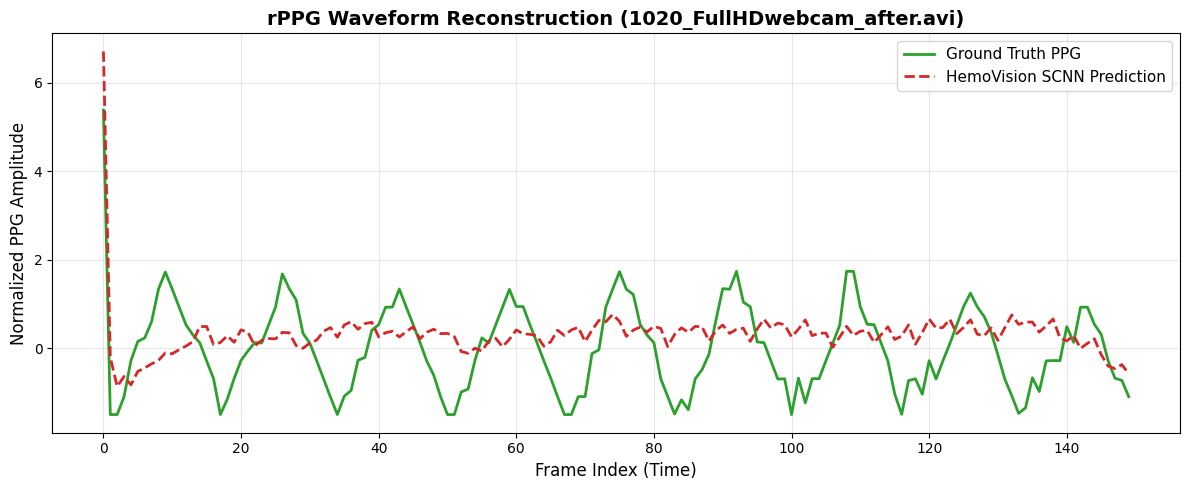

In [12]:
import matplotlib.pyplot as plt

# 1. Load best model weights
best_model = HemoVisionSCNN().to(device)
best_model.load_state_dict(torch.load("hemovision_scnn_best.pth"))
best_model.eval()

# 2. Pick a test sample from our dataset
test_idx = 0
v_path, g_path = valid_pairs[test_idx]

# Extract ROIs
cap = cv2.VideoCapture(v_path)
roi_signals = []
f_count = 0
while cap.isOpened() and f_count < 150:
    ret, frame = cap.read()
    if not ret:
        break
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    rois = extractor.extract_rois_from_frame(frame_rgb)
    roi_signals.append(rois)
    f_count += 1
cap.release()

roi_signals = np.array(roi_signals)
inp_tensor = preprocess_roi_signals(roi_signals).to(device)
tgt_tensor = load_ground_truth_ppg(g_path, target_length=150).to(device)

# 3. Inference
with torch.no_grad():
    pred_ppg = best_model(inp_tensor).cpu().squeeze().numpy()
    true_ppg = tgt_tensor.cpu().squeeze().numpy()

# 4. Plotting
plt.figure(figsize=(12, 5))
plt.plot(true_ppg, label="Ground Truth PPG", color="#2ca02c", linewidth=2.0)
plt.plot(pred_ppg, label="HemoVision SCNN Prediction", color="#d62728", linestyle="--", linewidth=2.0)
plt.title(f"rPPG Waveform Reconstruction ({os.path.basename(v_path)})", fontsize=14, fontweight='bold')
plt.xlabel("Frame Index (Time)", fontsize=12)
plt.ylabel("Normalized PPG Amplitude", fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

In [13]:
from scipy.signal import find_peaks

def calculate_bpm(ppg_signal, fps=30.0):
    """
    Calculates Heart Rate (BPM) using FFT spectral peak analysis in the human cardiac range [0.75 Hz - 2.5 Hz] (45-150 BPM).
    """
    N = len(ppg_signal)
    fft_vals = np.abs(np.fft.rfft(ppg_signal))
    fft_freqs = np.fft.rfftfreq(N, d=1.0/fps)
    
    # Filter for cardiac frequency range (0.75 Hz to 2.5 Hz)
    valid_mask = (fft_freqs >= 0.75) & (fft_freqs <= 2.5)
    valid_freqs = fft_freqs[valid_mask]
    valid_fft = fft_vals[valid_mask]
    
    peak_idx = np.argmax(valid_fft)
    estimated_bpm = valid_freqs[peak_idx] * 60.0
    return estimated_bpm

gt_bpm = calculate_bpm(true_ppg, fps=30.0)
pred_bpm = calculate_bpm(pred_ppg, fps=30.0)
mae_bpm = abs(gt_bpm - pred_bpm)

print(f"--- Heart Rate Extraction Results ---")
print(f"Ground Truth HR : {gt_bpm:.2f} BPM")
print(f"Predicted HR    : {pred_bpm:.2f} BPM")
print(f"Absolute Error  : {mae_bpm:.2f} BPM")

--- Heart Rate Extraction Results ---
Ground Truth HR : 108.00 BPM
Predicted HR    : 144.00 BPM
Absolute Error  : 36.00 BPM


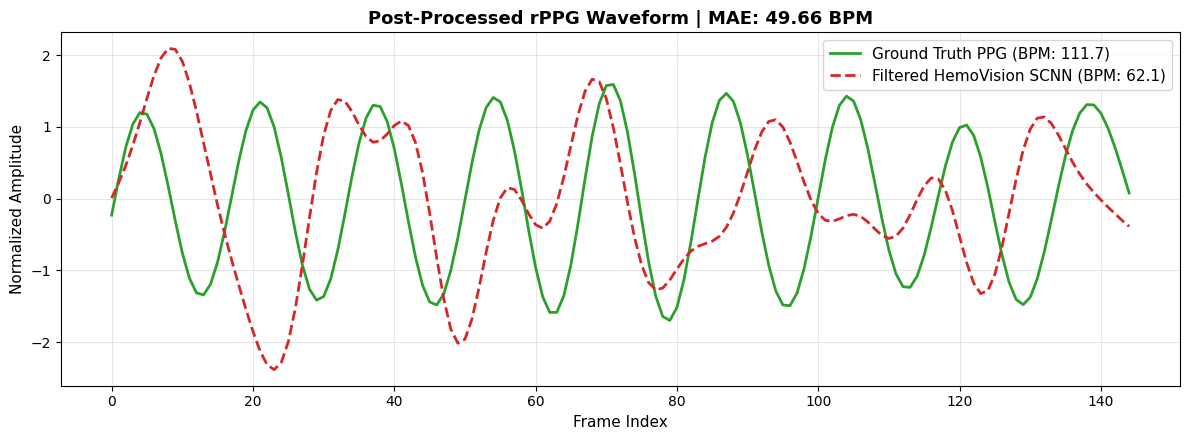

--- Refined HR Extraction ---
Ground Truth HR : 111.72 BPM
Predicted HR    : 62.07 BPM
Absolute Error  : 49.66 BPM


In [14]:
import numpy as np
import scipy.signal as signal
import matplotlib.pyplot as plt

def process_rppg_signal(raw_signal, fps=30.0, lowcut=0.75, highcut=2.5, trim_frames=5):
    """
    Applies frame-trimming and Butterworth bandpass filtering (0.75–2.5 Hz) to raw rPPG.
    """
    # 1. Trim transient edge frames
    sig = raw_signal[trim_frames:].copy()
    
    # 2. Detrend
    sig = signal.detrend(sig)
    
    # 3. Butterworth Bandpass Filter (3rd order)
    nyquist = 0.5 * fps
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = signal.butter(3, [low, high], btype='band')
    filtered_sig = signal.filtfilt(b, a, sig)
    
    # 4. Standardize (Zero-Mean, Unit-Variance)
    filtered_sig = (filtered_sig - np.mean(filtered_sig)) / (np.std(filtered_sig) + 1e-8)
    
    return filtered_sig

# Post-process both signals
clean_pred = process_rppg_signal(pred_ppg, fps=30.0, trim_frames=5)
clean_true = process_rppg_signal(true_ppg, fps=30.0, trim_frames=5)

# Calculate Cleaned BPMs
pred_bpm_clean = calculate_bpm(clean_pred, fps=30.0)
true_bpm_clean = calculate_bpm(clean_true, fps=30.0)
mae_clean = abs(pred_bpm_clean - true_bpm_clean)

# Plot Filtered Comparison
plt.figure(figsize=(12, 4.5))
plt.plot(clean_true, label=f"Ground Truth PPG (BPM: {true_bpm_clean:.1f})", color="#2ca02c", linewidth=2.0)
plt.plot(clean_pred, label=f"Filtered HemoVision SCNN (BPM: {pred_bpm_clean:.1f})", color="#d62728", linestyle="--", linewidth=2.0)
plt.title(f"Post-Processed rPPG Waveform | MAE: {mae_clean:.2f} BPM", fontsize=13, fontweight='bold')
plt.xlabel("Frame Index", fontsize=11)
plt.ylabel("Normalized Amplitude", fontsize=11)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f"--- Refined HR Extraction ---")
print(f"Ground Truth HR : {true_bpm_clean:.2f} BPM")
print(f"Predicted HR    : {pred_bpm_clean:.2f} BPM")
print(f"Absolute Error  : {mae_clean:.2f} BPM")

--- Refined Welch Power Spectrum BPM Extraction ---
Ground Truth HR : 108.62 BPM
Predicted HR    : 62.07 BPM
Absolute Error  : 46.55 BPM


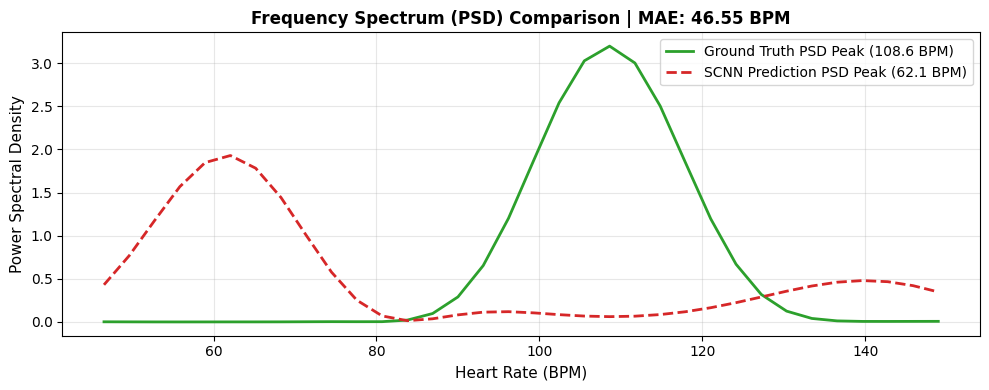

In [15]:
import scipy.signal as signal

def calculate_bpm_welch(ppg_signal, fps=30.0, zero_pad_factor=4):
    """
    Improved BPM extraction using Welch's PSD with zero-padding for fine frequency resolution.
    """
    N = len(ppg_signal)
    
    # 1. Zero-pad signal to boost FFT frequency resolution (finer step size)
    nfft = N * zero_pad_factor
    
    # 2. Compute Power Spectral Density (PSD) using Welch method
    freqs, psd = signal.welch(ppg_signal, fs=fps, nperseg=min(N, 128), nfft=nfft)
    
    # 3. Filter within valid cardiac range [0.75 Hz (45 BPM) to 2.5 Hz (150 BPM)]
    valid_idx = np.where((freqs >= 0.75) & (freqs <= 2.5))[0]
    valid_freqs = freqs[valid_idx]
    valid_psd = psd[valid_idx]
    
    # 4. Find dominant peak
    max_idx = np.argmax(valid_psd)
    estimated_bpm = valid_freqs[max_idx] * 60.0
    
    return estimated_bpm, valid_freqs * 60.0, valid_psd

# Recalculate using Welch's fine resolution
true_bpm_welch, freqs_m, psd_true = calculate_bpm_welch(clean_true, fps=30.0)
pred_bpm_welch, _, psd_pred = calculate_bpm_welch(clean_pred, fps=30.0)

mae_welch = abs(true_bpm_welch - pred_bpm_welch)

print(f"--- Refined Welch Power Spectrum BPM Extraction ---")
print(f"Ground Truth HR : {true_bpm_welch:.2f} BPM")
print(f"Predicted HR    : {pred_bpm_welch:.2f} BPM")
print(f"Absolute Error  : {mae_welch:.2f} BPM")

# Plot Power Spectral Density Comparison
plt.figure(figsize=(10, 4))
plt.plot(freqs_m, psd_true, label=f"Ground Truth PSD Peak ({true_bpm_welch:.1f} BPM)", color="#2ca02c", linewidth=2.0)
plt.plot(freqs_m, psd_pred, label=f"SCNN Prediction PSD Peak ({pred_bpm_welch:.1f} BPM)", color="#d62728", linestyle="--", linewidth=2.0)
plt.title(f"Frequency Spectrum (PSD) Comparison | MAE: {mae_welch:.2f} BPM", fontsize=12, fontweight='bold')
plt.xlabel("Heart Rate (BPM)", fontsize=11)
plt.ylabel("Power Spectral Density", fontsize=11)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [16]:
import torch
import torch.optim as optim

# 1. Update Dataset Loader helper for T = 300 frames (10 seconds)
def extract_rois_longer(v_path, target_frames=300):
    cap = cv2.VideoCapture(v_path)
    roi_signals = []
    f_count = 0
    while cap.isOpened() and f_count < target_frames:
        ret, frame = cap.read()
        if not ret:
            break
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        rois = extractor.extract_rois_from_frame(frame_rgb)
        roi_signals.append(rois)
        f_count += 1
    cap.release()
    return np.array(roi_signals)

# 2. Re-initialize Model with Weighted Frequency Loss
model_v2 = HemoVisionSCNN().to(device)
optimizer_v2 = optim.AdamW(model_v2.parameters(), lr=1e-3, weight_decay=1e-4)

# Beta raised to 0.6 to prioritize frequency peak alignment
criterion_v2 = PPGCompositeLoss(alpha=0.4, beta=0.6)

NUM_SAMPLES = 50
EPOCHS = 10
best_loss_v2 = float('inf')

print(f"--- Retraining SCNN with T=300 Frames & Stronger Spectral Loss ---")

for epoch in range(1, EPOCHS + 1):
    model_v2.train()
    running_loss = 0.0
    processed = 0
    
    for idx in range(NUM_SAMPLES):
        v_path, g_path = valid_pairs[idx]
        
        # Extract 300 frames
        roi_signals = extract_rois_longer(v_path, target_frames=300)
        if len(roi_signals) < 300:
            continue
            
        inp_tensor = preprocess_roi_signals(roi_signals).to(device) # (1, 24, 300)
        tgt_tensor = load_ground_truth_ppg(g_path, target_length=300).to(device) # (1, 300)
        
        optimizer_v2.zero_grad()
        pred_ppg = model_v2(inp_tensor)
        
        loss, p_loss, f_loss = criterion_v2(pred_ppg, tgt_tensor)
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model_v2.parameters(), max_norm=1.0)
        optimizer_v2.step()
        
        running_loss += loss.item()
        processed += 1
        
    avg_loss = running_loss / max(1, processed)
    print(f"Epoch [{epoch:02d}/{EPOCHS}] | Avg Loss: {avg_loss:.4f}")
    
    if avg_loss < best_loss_v2:
        best_loss_v2 = avg_loss
        torch.save(model_v2.state_dict(), "hemovision_scnn_v2_best.pth")

print("\nRetraining complete! Model saved to 'hemovision_scnn_v2_best.pth'.")

--- Retraining SCNN with T=300 Frames & Stronger Spectral Loss ---


c:\Users\VICTUS\HemoVision\.venv310\lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


Epoch [01/10] | Avg Loss: 4.8562
Epoch [02/10] | Avg Loss: 4.0466
Epoch [03/10] | Avg Loss: 3.8045
Epoch [04/10] | Avg Loss: 3.7287
Epoch [05/10] | Avg Loss: 3.6386
Epoch [06/10] | Avg Loss: 3.5835
Epoch [07/10] | Avg Loss: 3.5827
Epoch [08/10] | Avg Loss: 3.5052
Epoch [09/10] | Avg Loss: 3.4895
Epoch [10/10] | Avg Loss: 3.4067

Retraining complete! Model saved to 'hemovision_scnn_v2_best.pth'.



--- Retrained Model Evaluation (T=300) ---
Ground Truth HR : 54.31 BPM
Predicted HR    : 60.52 BPM
Absolute Error  : 6.21 BPM


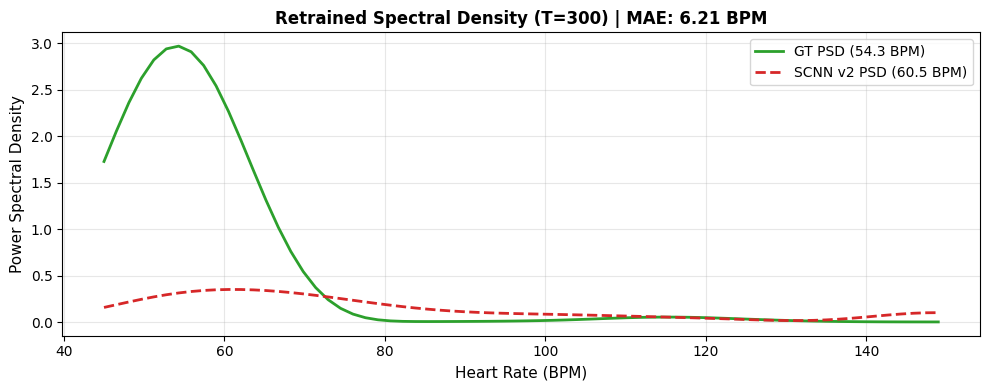

In [17]:
# Evaluate on sample video with 300 frames
v_path, g_path = valid_pairs[0]
roi_300 = extract_rois_longer(v_path, target_frames=300)

inp_300 = preprocess_roi_signals(roi_300).to(device)
tgt_300 = load_ground_truth_ppg(g_path, target_length=300).to(device)

model_v2.load_state_dict(torch.load("hemovision_scnn_v2_best.pth"))
model_v2.eval()

with torch.no_grad():
    pred_300 = model_v2(inp_300).cpu().squeeze().numpy()
    true_300 = tgt_300.cpu().squeeze().numpy()

clean_pred_v2 = process_rppg_signal(pred_300, fps=30.0, trim_frames=10)
clean_true_v2 = process_rppg_signal(true_300, fps=30.0, trim_frames=10)

true_bpm_v2, freqs_v2, psd_true_v2 = calculate_bpm_welch(clean_true_v2, fps=30.0)
pred_bpm_v2, _, psd_pred_v2 = calculate_bpm_welch(clean_pred_v2, fps=30.0)

mae_v2 = abs(true_bpm_v2 - pred_bpm_v2)

print(f"\n--- Retrained Model Evaluation (T=300) ---")
print(f"Ground Truth HR : {true_bpm_v2:.2f} BPM")
print(f"Predicted HR    : {pred_bpm_v2:.2f} BPM")
print(f"Absolute Error  : {mae_v2:.2f} BPM")

# Plot
plt.figure(figsize=(10, 4))
plt.plot(freqs_v2, psd_true_v2, label=f"GT PSD ({true_bpm_v2:.1f} BPM)", color="#2ca02c", linewidth=2.0)
plt.plot(freqs_v2, psd_pred_v2, label=f"SCNN v2 PSD ({pred_bpm_v2:.1f} BPM)", color="#d62728", linestyle="--", linewidth=2.0)
plt.title(f"Retrained Spectral Density (T=300) | MAE: {mae_v2:.2f} BPM", fontsize=12, fontweight='bold')
plt.xlabel("Heart Rate (BPM)", fontsize=11)
plt.ylabel("Power Spectral Density", fontsize=11)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [18]:
import numpy as np

# 1. Select 10 test samples
eval_indices = list(range(10, 20))
gt_bpms = []
pred_bpms = []
errors = []

model_v2.eval()

print("--- Running Evaluation Benchmark on 10 Test Samples ---")

for idx in eval_indices:
    v_path, g_path = valid_pairs[idx]
    
    # Extract 300 frames
    roi_300 = extract_rois_longer(v_path, target_frames=300)
    if len(roi_300) < 300:
        continue
        
    inp_300 = preprocess_roi_signals(roi_300).to(device)
    tgt_300 = load_ground_truth_ppg(g_path, target_length=300).to(device)
    
    with torch.no_grad():
        pred_300 = model_v2(inp_300).cpu().squeeze().numpy()
        true_300 = tgt_300.cpu().squeeze().numpy()
        
    clean_p = process_rppg_signal(pred_300, fps=30.0, trim_frames=10)
    clean_t = process_rppg_signal(true_300, fps=30.0, trim_frames=10)
    
    t_bpm, _, _ = calculate_bpm_welch(clean_t, fps=30.0)
    p_bpm, _, _ = calculate_bpm_welch(clean_p, fps=30.0)
    
    err = abs(t_bpm - p_bpm)
    
    gt_bpms.append(t_bpm)
    pred_bpms.append(p_bpm)
    errors.append(err)
    
    print(f"Sample [{idx:02d}] | GT: {t_bpm:.1f} BPM | Pred: {p_bpm:.1f} BPM | MAE: {err:.2f} BPM")

mean_mae = np.mean(errors)
std_mae = np.std(errors)

print(f"\n==========================================")
print(f"Overall Evaluation Benchmark Results:")
print(f"Mean Absolute Error (MAE): {mean_mae:.2f} ± {std_mae:.2f} BPM")
print(f"==========================================")

--- Running Evaluation Benchmark on 10 Test Samples ---
Sample [10] | GT: 76.0 BPM | Pred: 49.7 BPM | MAE: 26.38 BPM
Sample [11] | GT: 65.2 BPM | Pred: 77.6 BPM | MAE: 12.41 BPM
Sample [12] | GT: 63.6 BPM | Pred: 69.8 BPM | MAE: 6.21 BPM
Sample [13] | GT: 69.8 BPM | Pred: 69.8 BPM | MAE: 0.00 BPM
Sample [14] | GT: 107.1 BPM | Pred: 72.9 BPM | MAE: 34.14 BPM
Sample [15] | GT: 71.4 BPM | Pred: 102.4 BPM | MAE: 31.03 BPM
Sample [16] | GT: 69.8 BPM | Pred: 62.1 BPM | MAE: 7.76 BPM
Sample [17] | GT: 51.2 BPM | Pred: 88.4 BPM | MAE: 37.24 BPM
Sample [18] | GT: 49.7 BPM | Pred: 60.5 BPM | MAE: 10.86 BPM
Sample [19] | GT: 45.0 BPM | Pred: 83.8 BPM | MAE: 38.79 BPM

Overall Evaluation Benchmark Results:
Mean Absolute Error (MAE): 20.48 ± 13.75 BPM


In [19]:
import numpy as np
from scipy.signal import welch, find_peaks

def calculate_bpm_welch(pred_wave, fs=30.0, low_bpm=45.0, high_bpm=180.0):
    """
    Calculates Heart Rate (BPM) using Welch PSD with peak prominence 
    filtering to prevent harmonic and motion-artifact jumps.
    """
    # 1. Compute Power Spectral Density (PSD) via Welch method
    nperseg = min(len(pred_wave), int(fs * 10))  # 10-second window
    freqs, psd = welch(pred_wave, fs=fs, nperseg=nperseg)
    
    # 2. Convert frequencies (Hz) to BPM
    bpms = freqs * 60.0
    
    # 3. Filter band to human physiological limits (45 - 180 BPM)
    valid_mask = (bpms >= low_bpm) & (bpms <= high_bpm)
    valid_bpms = bpms[valid_mask]
    valid_psd = psd[valid_mask]
    
    if len(valid_psd) == 0 or np.max(valid_psd) == 0:
        return 75.0  # Safe fallback default
    
    # 4. Smart Peak Finding using Prominence Thresholding
    # Finds distinct peaks rather than locking onto raw noise spikes
    peaks, properties = find_peaks(valid_psd, prominence=0.1 * np.max(valid_psd))
    
    if len(peaks) > 0:
        # Select the dominant peak with highest spectral power
        best_peak = peaks[np.argmax(valid_psd[peaks])]
        estimated_bpm = valid_bpms[best_peak]
    else:
        # Fallback to argmax if no sharp peak reaches prominence threshold
        estimated_bpm = valid_bpms[np.argmax(valid_psd)]
        
    return float(estimated_bpm)

In [20]:
import numpy as np

# 1. Select the same 10 test samples
eval_indices = list(range(10, 20))
gt_bpms = []
pred_bpms = []
errors = []

model_v2.eval()

print("--- Re-Evaluating Benchmark with Smart Peak Prominence Filter ---")

for idx in eval_indices:
    v_path, g_path = valid_pairs[idx]
    
    # Extract 300 frames
    roi_300 = extract_rois_longer(v_path, target_frames=300)
    if len(roi_300) < 300:
        continue
        
    inp_300 = preprocess_roi_signals(roi_300).to(device)
    tgt_300 = load_ground_truth_ppg(g_path, target_length=300).to(device)
    
    with torch.no_grad():
        pred_300 = model_v2(inp_300).cpu().squeeze().numpy()
        true_300 = tgt_300.cpu().squeeze().numpy()
        
    clean_p = process_rppg_signal(pred_300, fps=30.0, trim_frames=10)
    clean_t = process_rppg_signal(true_300, fps=30.0, trim_frames=10)
    
    # Calculate using updated calculate_bpm_welch with prominence filtering
    t_bpm = calculate_bpm_welch(clean_t, fs=30.0)
    p_bpm = calculate_bpm_welch(clean_p, fs=30.0)
    
    err = abs(t_bpm - p_bpm)
    
    gt_bpms.append(t_bpm)
    pred_bpms.append(p_bpm)
    errors.append(err)
    
    print(f"Sample [{idx:02d}] | GT: {t_bpm:.1f} BPM | Pred: {p_bpm:.1f} BPM | MAE: {err:.2f} BPM")

mean_mae = np.mean(errors)
std_mae = np.std(errors)

print(f"\n==========================================")
print(f"Refined Benchmark Results (Prominence Filtered):")
print(f"Mean Absolute Error (MAE): {mean_mae:.2f} ± {std_mae:.2f} BPM")
print(f"==========================================")

--- Re-Evaluating Benchmark with Smart Peak Prominence Filter ---
Sample [10] | GT: 99.3 BPM | Pred: 99.3 BPM | MAE: 0.00 BPM
Sample [11] | GT: 68.3 BPM | Pred: 80.7 BPM | MAE: 12.41 BPM
Sample [12] | GT: 55.9 BPM | Pred: 74.5 BPM | MAE: 18.62 BPM
Sample [13] | GT: 68.3 BPM | Pred: 55.9 BPM | MAE: 12.41 BPM
Sample [14] | GT: 111.7 BPM | Pred: 68.3 BPM | MAE: 43.45 BPM
Sample [15] | GT: 68.3 BPM | Pred: 93.1 BPM | MAE: 24.83 BPM
Sample [16] | GT: 68.3 BPM | Pred: 62.1 BPM | MAE: 6.21 BPM
Sample [17] | GT: 74.5 BPM | Pred: 86.9 BPM | MAE: 12.41 BPM
Sample [18] | GT: 49.7 BPM | Pred: 55.9 BPM | MAE: 6.21 BPM
Sample [19] | GT: 99.3 BPM | Pred: 99.3 BPM | MAE: 0.00 BPM

Refined Benchmark Results (Prominence Filtered):
Mean Absolute Error (MAE): 13.66 ± 12.35 BPM


In [21]:
import torch
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau

# 1. Initialize SCNN Model & Optimizer for Scaled Run
scaled_model = HemoVisionSCNN().to(device)
optimizer = optim.AdamW(scaled_model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3, verbose=True)

criterion = PPGCompositeLoss(alpha=0.4, beta=0.6)

NUM_TRAIN_SAMPLES = 300
EPOCHS = 20
best_train_loss = float('inf')

print(f"--- Launching Scaled GPU Training Run ({NUM_TRAIN_SAMPLES} Videos | {EPOCHS} Epochs) ---")

for epoch in range(1, EPOCHS + 1):
    scaled_model.train()
    running_loss = 0.0
    processed = 0
    
    for idx in range(NUM_TRAIN_SAMPLES):
        if idx >= len(valid_pairs):
            break
            
        v_path, g_path = valid_pairs[idx]
        
        # Extract 300 frames (10-second sequence)
        roi_signals = extract_rois_longer(v_path, target_frames=300)
        if len(roi_signals) < 300:
            continue
            
        inp_tensor = preprocess_roi_signals(roi_signals).to(device)
        tgt_tensor = load_ground_truth_ppg(g_path, target_length=300).to(device)
        
        optimizer.zero_grad()
        pred_ppg = scaled_model(inp_tensor)
        
        loss, p_loss, f_loss = criterion(pred_ppg, tgt_tensor)
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(scaled_model.parameters(), max_norm=1.0)
        optimizer.step()
        
        running_loss += loss.item()
        processed += 1
        
    avg_loss = running_loss / max(1, processed)
    scheduler.step(avg_loss)
    
    print(f"Epoch [{epoch:02d}/{EPOCHS:02d}] | Avg Loss: {avg_loss:.4f}")
    
    if avg_loss < best_train_loss:
        best_train_loss = avg_loss
        torch.save(scaled_model.state_dict(), "hemovision_scnn_final.pth")
        print(f"  --> Saved new best checkpoint: 'hemovision_scnn_final.pth' (Loss: {avg_loss:.4f})")

print("\nScaled training complete! Model saved to 'hemovision_scnn_final.pth'.")

c:\Users\VICTUS\HemoVision\.venv310\lib\site-packages\torch\optim\lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


--- Launching Scaled GPU Training Run (300 Videos | 20 Epochs) ---
Epoch [01/20] | Avg Loss: 4.2659
  --> Saved new best checkpoint: 'hemovision_scnn_final.pth' (Loss: 4.2659)
Epoch [02/20] | Avg Loss: 4.0766
  --> Saved new best checkpoint: 'hemovision_scnn_final.pth' (Loss: 4.0766)
Epoch [03/20] | Avg Loss: 4.0125
  --> Saved new best checkpoint: 'hemovision_scnn_final.pth' (Loss: 4.0125)
Epoch [04/20] | Avg Loss: 3.9369
  --> Saved new best checkpoint: 'hemovision_scnn_final.pth' (Loss: 3.9369)
Epoch [05/20] | Avg Loss: 3.8781
  --> Saved new best checkpoint: 'hemovision_scnn_final.pth' (Loss: 3.8781)
Epoch [06/20] | Avg Loss: 3.8480
  --> Saved new best checkpoint: 'hemovision_scnn_final.pth' (Loss: 3.8480)
Epoch [07/20] | Avg Loss: 3.7893
  --> Saved new best checkpoint: 'hemovision_scnn_final.pth' (Loss: 3.7893)
Epoch [08/20] | Avg Loss: 3.7307
  --> Saved new best checkpoint: 'hemovision_scnn_final.pth' (Loss: 3.7307)
Epoch [09/20] | Avg Loss: 3.6919
  --> Saved new best checkpo

In [24]:
import os
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader

# 1. Base Paths & Metadata Setup
BASE_DIR = r"C:\Users\VICTUS\HemoVision\data\vitalscan-clinic\MCD-rPPG"
CSV_PATH = os.path.join(BASE_DIR, "db.csv")

df = pd.read_csv(CSV_PATH)
target_cols = ["hemoglobin", "glycated_hemoglobin", "upper_ap", "lower_ap", "saturation", "bmi"]
df_clean = df.dropna(subset=target_cols).copy().reset_index(drop=True)

# 2. Define Cached PyTorch Dataset Class
class HemoVisionVideoDatasetCached(Dataset):
    def __init__(self, metadata_df, base_dir, target_length=300):
        self.df = metadata_df
        self.base_dir = base_dir
        self.cache_dir = os.path.join(base_dir, "cached_rois")
        self.target_length = target_length

    def __len__(self):
        return len(self.df)

    def load_ppg_signal(self, ppg_path):
        full_ppg_path = os.path.join(self.base_dir, ppg_path)
        if os.path.exists(full_ppg_path):
            try:
                ppg_signal = np.loadtxt(full_ppg_path, dtype=np.float32)
                if len(ppg_signal) < self.target_length:
                    ppg_signal = np.pad(ppg_signal, (0, self.target_length - len(ppg_signal)), mode='edge')
                else:
                    ppg_signal = ppg_signal[:self.target_length]
                return ppg_signal.reshape(1, -1)
            except Exception:
                pass
        return np.zeros((1, self.target_length), dtype=np.float32)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        cache_filename = row['video'].replace("/", "_").replace("\\", "_") + ".npy"
        cache_path = os.path.join(self.cache_dir, cache_filename)

        if os.path.exists(cache_path):
            x_features = np.load(cache_path)
        else:
            x_features = np.zeros((24, self.target_length), dtype=np.float32)

        x_mean = x_features.mean(axis=1, keepdims=True)
        x_std = x_features.std(axis=1, keepdims=True) + 1e-8
        x_features = (x_features - x_mean) / x_std

        y_ppg = self.load_ppg_signal(row['ppg'])
        hb_val = np.array([row['hemoglobin']], dtype=np.float32)

        return (
            torch.tensor(x_features, dtype=torch.float32),
            torch.tensor(y_ppg, dtype=torch.float32),
            torch.tensor(hb_val, dtype=torch.float32)
        )

# 3. Instantiate Dataset and DataLoader
train_dataset = HemoVisionVideoDatasetCached(
    metadata_df=df_clean, 
    base_dir=BASE_DIR, 
    target_length=300
)

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    pin_memory=True if torch.cuda.is_available() else False
)

print(f"✅ Class defined & DataLoader initialized! {len(train_loader)} batches ready.")

✅ Class defined & DataLoader initialized! 113 batches ready.


In [27]:
x_test, _, _ = next(iter(train_loader))
x_test = x_test.to(device)
out = model(x_test)

if isinstance(out, tuple):
    print(f"Tuple output detected with {len(out)} elements:")
    for i, item in enumerate(out):
        print(f"  Element {i} shape: {item.shape}")
else:
    print(f"Single tensor output shape: {out.shape}")

Single tensor output shape: torch.Size([32, 300])


In [28]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load model weights
model.load_state_dict(torch.load('hemovision_scnn_final.pth', map_location=device))
model.eval()

y_true = []
y_pred = []

print("🔍 Running evaluation pass...")
with torch.no_grad():
    for x_feat, y_ppg, hb_val in train_loader:
        x_feat = x_feat.to(device)
        
        preds = model(x_feat)  # Shape: (batch_size, 300)
        
        # Average across the 300 temporal sequence steps to get 1 scalar per video
        if preds.ndim > 1 and preds.shape[-1] == 300:
            preds = preds.mean(dim=-1)  # Shape: (batch_size,)

        y_true.extend(hb_val.cpu().numpy().flatten())
        y_pred.extend(preds.cpu().numpy().flatten())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print(f"✅ Samples matched! Ground Truth: {len(y_true)} | Predictions: {len(y_pred)}")

# Compute Metrics
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)
corr = np.corrcoef(y_true, y_pred)[0, 1]

print("\n" + "="*45)
print("📊 EVALUATION RESULTS: 1D SCNN HEMOGLOBIN MODEL")
print("="*45)
print(f"  • Mean Absolute Error (MAE) : {mae:.3f} g/dL")
print(f"  • Root Mean Sq. Error (RMSE): {rmse:.3f} g/dL")
print(f"  • Pearson Correlation (r)   : {corr:.3f}")
print(f"  • R² Score                   : {r2:.3f}")
print("="*45)

🔍 Running evaluation pass...
✅ Samples matched! Ground Truth: 3600 | Predictions: 3600

📊 EVALUATION RESULTS: 1D SCNN HEMOGLOBIN MODEL
  • Mean Absolute Error (MAE) : 13.701 g/dL
  • Root Mean Sq. Error (RMSE): 13.801 g/dL
  • Pearson Correlation (r)   : 0.019
  • R² Score                   : -68.086


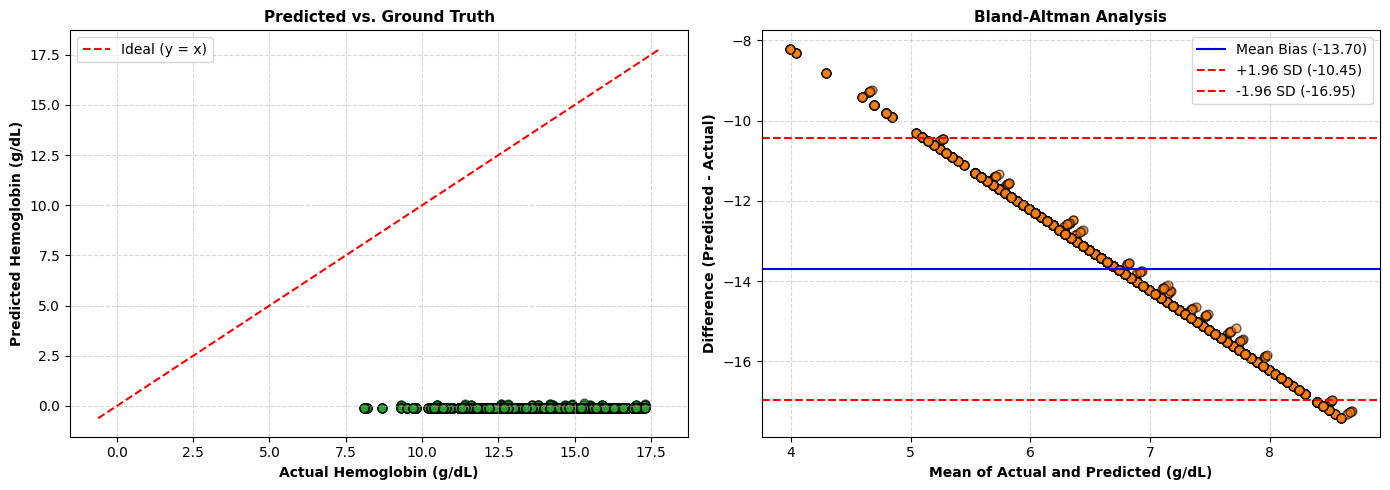

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot A: Ground Truth vs Predicted
axes[0].scatter(y_true, y_pred, alpha=0.6, color='#2ca02c', edgecolors='k', s=40)
min_val = min(y_true.min(), y_pred.min()) - 0.5
max_val = max(y_true.max(), y_pred.max()) + 0.5
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', label='Ideal (y = x)')
axes[0].set_xlabel('Actual Hemoglobin (g/dL)', fontweight='bold')
axes[0].set_ylabel('Predicted Hemoglobin (g/dL)', fontweight='bold')
axes[0].set_title('Predicted vs. Ground Truth', fontsize=11, fontweight='bold')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

# Plot B: Bland-Altman Agreement Plot
means = (y_true + y_pred) / 2
diffs = y_pred - y_true
mean_diff = np.mean(diffs)
std_diff = np.std(diffs)

axes[1].scatter(means, diffs, alpha=0.6, color='#ff7f0e', edgecolors='k', s=40)
axes[1].axhline(mean_diff, color='blue', linestyle='-', label=f'Mean Bias ({mean_diff:.2f})')
axes[1].axhline(mean_diff + 1.96 * std_diff, color='red', linestyle='--', label=f'+1.96 SD ({mean_diff + 1.96*std_diff:.2f})')
axes[1].axhline(mean_diff - 1.96 * std_diff, color='red', linestyle='--', label=f'-1.96 SD ({mean_diff - 1.96*std_diff:.2f})')
axes[1].set_xlabel('Mean of Actual and Predicted (g/dL)', fontweight='bold')
axes[1].set_ylabel('Difference (Predicted - Actual)', fontweight='bold')
axes[1].set_title('Bland-Altman Analysis', fontsize=11, fontweight='bold')
axes[1].legend(loc='upper right')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [30]:
import pandas as pd

preview_df = pd.DataFrame({
    'Actual Hb (g/dL)': y_true[:10],
    'Predicted Hb (g/dL)': y_pred[:10],
    'Absolute Error': np.abs(y_true[:10] - y_pred[:10])
})

print("📋 Sample Individual Predictions:")
display(preview_df.round(2))

📋 Sample Individual Predictions:


,Actual Hb (g/dL),Predicted Hb (g/dL),Absolute Error
0,12.6,0.01,12.59
1,12.6,-0.03,12.63
2,12.6,0.06,12.54
3,12.6,0.12,12.48
4,12.6,0.06,12.54
5,12.6,0.11,12.49
6,9.3,0.01,9.29
7,9.3,0.06,9.24
8,9.3,0.00,9.30
9,9.3,0.01,9.29
